In [24]:
import numpy as np
import matplotlib.pyplot as plt


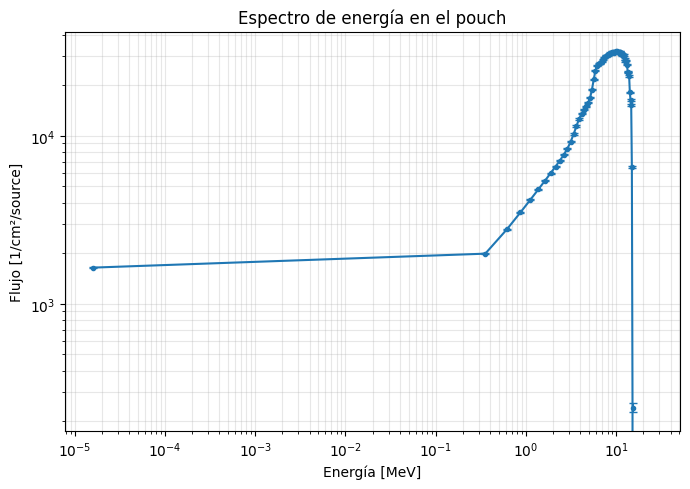

In [25]:
archivo = "energy_pouch.out"

E = []
flujo = []
error = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        partes = linea.split()

        if len(partes) < 4:
            continue

        try:
            e1 = float(partes[0].replace("D", "E"))
            e2 = float(partes[1].replace("D", "E"))
            val = float(partes[2].replace("D", "E"))
            err = float(partes[3].replace("D", "E"))
        except:
            continue

        E.append(np.sqrt(e1 * e2))
        flujo.append(val)
        error.append(err)

E = np.array(E)
flujo = np.array(flujo)
error = np.array(error)

plt.figure(figsize=(7,5))

plt.errorbar(
    E,
    flujo,
    yerr=flujo * error,
    fmt="o-",
    capsize=3,
    markersize=3
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el pouch")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

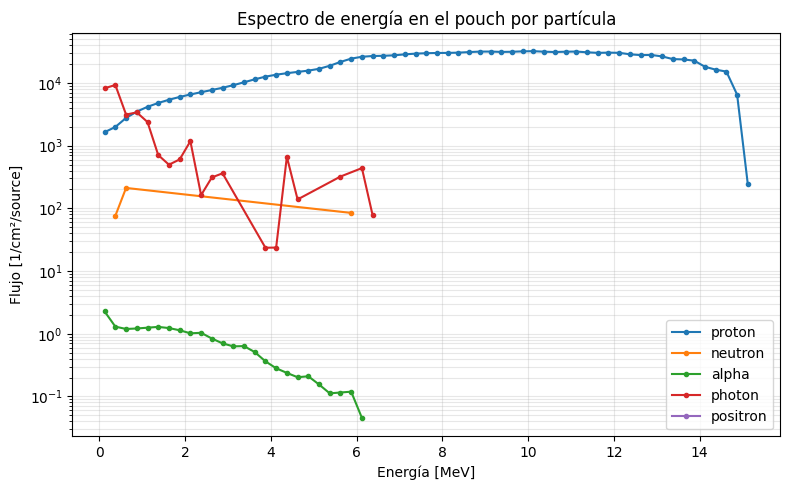

In [26]:
archivo = "energy_pouch.out"

E = []

proton = []
neutron = []
alpha = []
photon = []
positron = []

err_proton = []
err_neutron = []
err_alpha = []
err_photon = []
err_positron = []

leer = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("#  e-lower"):
            leer = True
            continue

        if leer:
            partes = linea.split()

            if len(partes) != 12:
                continue

            try:
                valores = [float(p.replace("D", "E")) for p in partes]
            except:
                continue

            e1, e2 = valores[0], valores[1]

            E.append((e1 + e2) / 2)

            proton.append(valores[2])
            err_proton.append(valores[3])

            neutron.append(valores[4])
            err_neutron.append(valores[5])

            alpha.append(valores[6])
            err_alpha.append(valores[7])

            photon.append(valores[8])
            err_photon.append(valores[9])

            positron.append(valores[10])
            err_positron.append(valores[11])

E = np.array(E)

datos = {
    "proton": np.array(proton),
    "neutron": np.array(neutron),
    "alpha": np.array(alpha),
    "photon": np.array(photon),
    "positron": np.array(positron),
}

plt.figure(figsize=(8,5))

for nombre, y in datos.items():
    mask = y > 0
    plt.plot(E[mask], y[mask], marker="o", markersize=3, linewidth=1.5, label=nombre)

plt.yscale("log")
plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el pouch por partícula")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

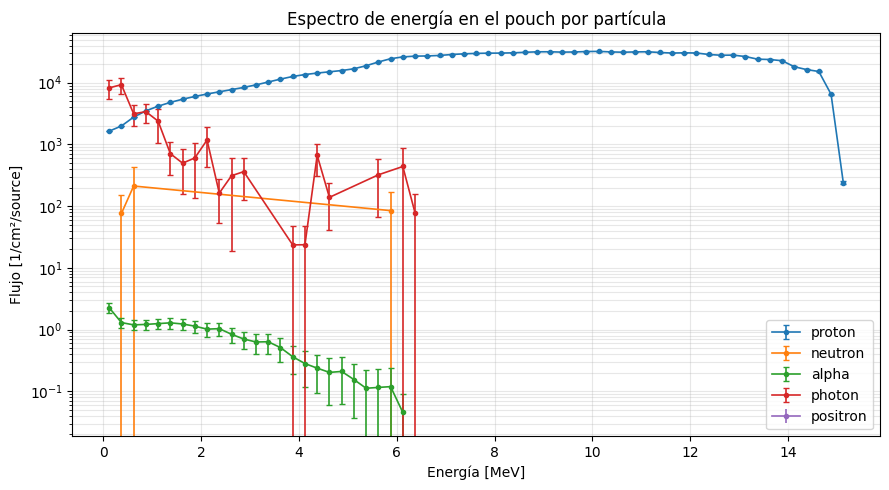

In [27]:
archivo = "energy_pouch.out"

E = []
datos = {
    "proton": {"y": [], "err": []},
    "neutron": {"y": [], "err": []},
    "alpha": {"y": [], "err": []},
    "photon": {"y": [], "err": []},
    "positron": {"y": [], "err": []},
}

leer = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("#  e-lower"):
            leer = True
            continue

        if leer:
            partes = linea.split()

            if len(partes) != 12:
                continue

            try:
                valores = [float(p.replace("D", "E")) for p in partes]
            except:
                continue

            e1, e2 = valores[0], valores[1]
            E.append((e1 + e2) / 2)

            datos["proton"]["y"].append(valores[2])
            datos["proton"]["err"].append(valores[3])

            datos["neutron"]["y"].append(valores[4])
            datos["neutron"]["err"].append(valores[5])

            datos["alpha"]["y"].append(valores[6])
            datos["alpha"]["err"].append(valores[7])

            datos["photon"]["y"].append(valores[8])
            datos["photon"]["err"].append(valores[9])

            datos["positron"]["y"].append(valores[10])
            datos["positron"]["err"].append(valores[11])

E = np.array(E)

plt.figure(figsize=(9, 5))

for nombre in datos:
    y = np.array(datos[nombre]["y"])
    err_rel = np.array(datos[nombre]["err"])

    yerr = y * err_rel

    mask = y > 0

    plt.errorbar(
        E[mask],
        y[mask],
        yerr=yerr[mask],
        marker="o",
        markersize=3,
        linewidth=1.2,
        capsize=2,
        label=nombre
    )

plt.yscale("log")
plt.xlabel("Energía [MeV]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title("Espectro de energía en el pouch por partícula")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
y_proton = np.array(datos["proton"]["y"])
y_err_proton = np.array(datos["proton"]["err"])

E_max_proton = np.max(E[y_proton > 0])
err_proton_max = np.max(y_err_proton[y_proton > 0])

print(f"{E_max_proton} ± {err_proton_max}")

15.125 ± 0.0622
